#0. Imports and I/O section

In [222]:
###
import os
import zipfile
import numpy as np
import pandas as pd
import copy
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
# import tensorflow as tf
import shutil
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix
import seaborn as sns
import time
import h5py
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
from torchvision import models
from PIL import ImageFile
pd.set_option('display.max_columns', None)

In [223]:
# import torch_xla.core.xla_model as xm # for TPU
# device = xm.xla_device() # for TPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # for NVIDIA
print("Using device:", device)

Using device: cuda


In [224]:
# !pip install "numpy<2"
# !pip install opencv-python
# !pip install imblearn

In [225]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
# print(os.listdir())
# print(os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [226]:
os.chdir('/content/drive/My Drive/CS7643_project')

In [227]:
#!unzip -q "archive.zip" -d "/content/drive/My Drive/7643_finalproject02192025/extract"

#1. HAM 1000 Analysis: Transfer Learning from ResNet trained on ImageNet - No Metadata

In [228]:
# os.chdir('/content/drive/My Drive/7643_finalproject02192025/extract') ## small data is in extract

In [229]:
metadata_ham10000 = pd.read_csv(r"MNIST-HAM10000/HAM10000_metadata.csv")
# binary_map = {
#     "nv": "benign",
#     "bkl":"benign",
#     "df": "benign",
#     "vasc": "benign",
#     "mel": "Not Benign",
#     "bcc":  "Not Benign",
#     "akiec":  "Not Benign"
# }

binary_map = {
    "nv": 0,
    "bkl": 0,
    "df": 0,
    "vasc": 0,
    "mel": 1,
    "bcc":  1,
    "akiec": 1
}

metadata_ham10000["target"] = metadata_ham10000["dx"].map(binary_map)
# print(metadata.target.unique())

In [230]:
lesion_counts = metadata_ham10000['lesion_id'].value_counts()
metadata_ham10000['duplicates'] = metadata_ham10000['lesion_id'].map(lambda x: 'duplicated' if lesion_counts[x] > 1 else 'unduplicated')
metadata_ham10000['age'] = metadata_ham10000['age'].fillna(metadata_ham10000['age'].median())
metadata_ham10000['sex'] = metadata_ham10000['sex'].fillna('unknown')
metadata_ham10000['localization'] = metadata_ham10000['localization'].fillna('unknown')
# metadata_ham10000 = metadata_ham10000.groupby('lesion_id').sample(n=1, random_state=42).reset_index(drop=True)

In [231]:
# print(metadata.head())

In [232]:
## randomly select one image_id for the duplicated ids, if not duplicated, just select the unique one
#metadata_unique = metadata[metadata['duplicates'] == 'unduplicated'].reset_index()
#metadata_unique.drop(['index'], axis=1, inplace=True)

In [233]:
# print(metadata_ham10000.shape)

In [234]:
base_dir = r"MNIST-HAM10000/"
metadata_ham10000['image_path'] = metadata_ham10000['image_id'] + '.jpg'
metadata_ham10000['image_folder'] = np.where(metadata_ham10000['image_id'].str.slice(start=6, stop=12).astype(int)>29305, \
                            'HAM10000_images_part_2/', 'HAM10000_images_part_1/')
metadata_ham10000['full_path'] = (base_dir + metadata_ham10000['image_folder'] + metadata_ham10000['image_path'])
##train_val_df, test_df = train_test_split(metadata, test_size=0.2, stratify=metadata['dx'], random_state=42)
##train_df, val_df = train_test_split(train_val_df, test_size=0.2, stratify=train_val_df['dx'], random_state=42)

In [235]:
train_val_ham10000_df, test_ham10000_df = train_test_split(metadata_ham10000, test_size=0.2, stratify=metadata_ham10000['target'], random_state=42)
train_ham10000_df, val_ham10000_df = train_test_split(train_val_ham10000_df, test_size=0.2, stratify=train_val_ham10000_df['target'], random_state=42)

In [236]:
# def copy_images(df, target_root):
#     for _, row in df.iterrows():
#         #class_dir = os.path.join(target_root,(row['dx']))
#         class_dir = os.path.join(target_root,(row['target']))
#         os.makedirs(class_dir, exist_ok=True)
#         shutil.copyfile(row['full_path'], os.path.join(class_dir, row['image_path']))

# # Create base folders
# os.makedirs('data/train', exist_ok=True)
# os.makedirs('data/val', exist_ok=True)
# os.makedirs('data/test', exist_ok=True)

# copy_images(train_df, 'data/train')
# copy_images(val_df, 'data/val')
# copy_images(test_df, 'data/test') ## only takes 1m 1s

In [237]:
# transforms for training dataset
IMG_SIZE = (139, 139)
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

# Transforms for validation & test (no augmentation)
val_test_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
])

In [238]:
class HAMDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.classes = sorted(self.df['target'].unique())
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['full_path']).convert('RGB')
        label = self.class_to_idx[row['target']]
        if self.transform:
            image = self.transform(image)
        return image, label

In [239]:
train_dataset_ham10000 = HAMDataset(train_ham10000_df, transform=train_transforms)
val_dataset_ham10000 = HAMDataset(val_ham10000_df, transform=val_test_transforms)
test_dataset_ham10000 = HAMDataset(test_ham10000_df, transform=val_test_transforms)

train_loader_ham10000 = DataLoader(train_dataset_ham10000, batch_size=32, shuffle=True)
val_loader_ham10000 = DataLoader(val_dataset_ham10000, batch_size=32, shuffle=False)
test_loader_ham10000 = DataLoader(test_dataset_ham10000, batch_size=32, shuffle=False)

In [240]:
# images, labels = next(iter(train_loader))
# print("Image batch shape:", images.shape)
# print("Label batch shape:", labels.shape)

# # Move batch to GPU
# images = images.to(device)
# labels = labels.to(device)
# print("On device:", images.device)

In [241]:
# Load pretrained ResNet101 - freeze all layers except for the last one for classification learning
model = models.resnet101(pretrained=True)

# Optionally freeze all layers (for transfer learning)
for param in model.parameters():
    param.requires_grad = False

# Replace the final FC layer
num_classes = len(train_dataset_ham10000.classes)  # Should be 7 for HAM10000
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Unfreeze the last ResNet block + FC for fine-tuning
for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True

# Move model to GPU
model = model.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [242]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        """
        Focal Loss for classification tasks.
        Args:
            alpha (tensor): class weights (shape: [num_classes])
            gamma (float): focusing parameter
            reduction (str): 'mean', 'sum', or 'none'
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        loss = (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

In [243]:
def evaluate_model_no_metadata(model, dataloader, device):
    model.eval()
    total = 0
    correct = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(probs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    print(f"✅ Eval Accuracy: {accuracy:.2f}%")
    return all_preds, all_labels, all_probs

In [244]:
# loss function seetings
class_count_ham10000 = metadata_ham10000['target'].value_counts()
class_ratio_ham10000 = class_count_ham10000[0]/class_count_ham10000[1]
class_weights_ham10000 = torch.tensor([1.0, class_ratio_ham10000], dtype=torch.float32).to(device)
criterion_ham10000 = FocalLoss(alpha=class_weights_ham10000, gamma=2).to(device)

In [245]:
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [246]:
EPOCHS = 50
save_path = '1_ham10000_pretrained_no_metadata.pth'
best_f1 = 0
# optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
optimizer = optim.Adam(model.parameters(), lr=5e-5)

In [248]:
# training + best model selection on validation data
start_time = time.perf_counter()
for epoch in range(EPOCHS):
    print(f"\n🚀 Epoch {epoch + 1}/{EPOCHS}")
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(train_loader_ham10000, desc=f"Training Epoch {epoch+1}/{EPOCHS}")

    for images, labels in loop:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion_ham10000(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

    # 🎯 Training summary
    train_loss = running_loss / len(train_loader_ham10000)
    train_acc = 100 * correct / total
    print(f"✅ Training Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")

    # 🧪 VALIDATION
    val_preds, val_labels, val_probs = evaluate_model_no_metadata(model, val_loader_ham10000, device)

    f1 = f1_score(val_labels, val_preds)
    auc = roc_auc_score(val_labels, val_probs)
    cm = confusion_matrix(val_labels, val_preds)

    print(f"📊 Validation F1 Score: {f1:.4f}")
    print(f"📈 Validation AUC: {auc:.4f}")
    print(f"🧾 Confusion Matrix:\n{cm}")

    # 💾 Save best model by F1
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), save_path)
        model_ham10000_pretrained_no_metadata = copy.deepcopy(model)
        print(f"💾 Saved new best model with F1: {best_f1:.4f}")

end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.4f} seconds")


🚀 Epoch 1/50


Training Epoch 1/50: 100%|██████████| 201/201 [01:25<00:00,  2.35it/s, acc=79.8, loss=0.112]


✅ Training Loss: 0.2466 | Accuracy: 79.78%
✅ Eval Accuracy: 81.85%
📊 Validation F1 Score: 0.6589
📈 Validation AUC: 0.9268
🧾 Confusion Matrix:
[[1031  259]
 [  32  281]]

🚀 Epoch 2/50


Training Epoch 2/50: 100%|██████████| 201/201 [01:25<00:00,  2.34it/s, acc=80.3, loss=0.251]


✅ Training Loss: 0.2364 | Accuracy: 80.26%
✅ Eval Accuracy: 84.28%
📊 Validation F1 Score: 0.6842
📈 Validation AUC: 0.9287
🧾 Confusion Matrix:
[[1078  212]
 [  40  273]]

🚀 Epoch 3/50


...

✅ Training Loss: 0.1495 | Accuracy: 88.59%
✅ Eval Accuracy: 88.27%
📊 Validation F1 Score: 0.7202
📈 Validation AUC: 0.9305
🧾 Confusion Matrix:
[[1173  117]
 [  71  242]]

🚀 Epoch 49/50


Training Epoch 49/50: 100%|██████████| 201/201 [01:24<00:00,  2.37it/s, acc=88, loss=0.162]


✅ Training Loss: 0.1558 | Accuracy: 87.99%
✅ Eval Accuracy: 87.77%
📊 Validation F1 Score: 0.7224
📈 Validation AUC: 0.9391
🧾 Confusion Matrix:
[[1152  138]
 [  58  255]]

🚀 Epoch 50/50


Training Epoch 50/50: 100%|██████████| 201/201 [01:23<00:00,  2.41it/s, acc=88.8, loss=0.277]


✅ Training Loss: 0.1532 | Accuracy: 88.77%
✅ Eval Accuracy: 89.08%
📊 Validation F1 Score: 0.7368
📈 Validation AUC: 0.9384
🧾 Confusion Matrix:
[[1183  107]
 [  68  245]]
Execution time: 5134.3851 seconds


✅ Eval Accuracy: 86.87%
📊 Test F1 Score: 0.7022
📈 Test AUC: 0.9326
🧾 Test Confusion Matrix:


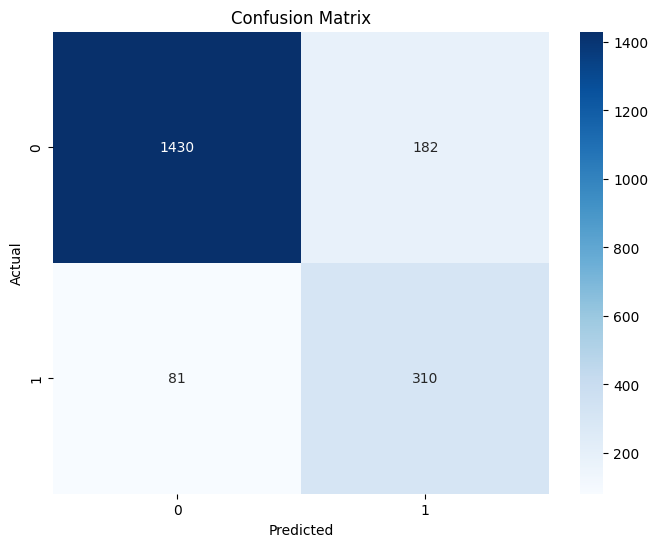

In [249]:
# evaluate on test dataset
test_preds, test_labels, test_probs = evaluate_model_no_metadata(model_ham10000_pretrained_no_metadata, test_loader_ham10000, device)
f1 = f1_score(test_labels, test_preds)
auc = roc_auc_score(test_labels, test_probs)
cm = confusion_matrix(test_labels, test_preds)

print(f"📊 Test F1 Score: {f1:.4f}")
print(f"📈 Test AUC: {auc:.4f}")
print(f"🧾 Test Confusion Matrix:")
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_dataset_ham10000.classes, yticklabels=train_dataset_ham10000.classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#2. HAM 1000 Analysis: Transfer Learning from ResNet trained on ImageNet - With Metadata

In [250]:
freeze_resnet = True

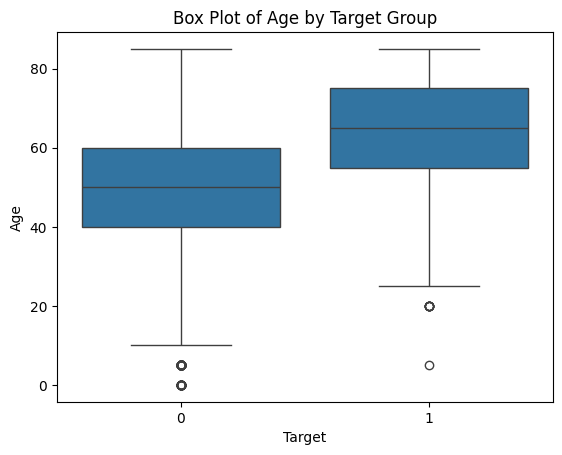

In [251]:
sns.boxplot(x='target', y='age', data=metadata_ham10000)
plt.title('Box Plot of Age by Target Group')
plt.xlabel('Target')
plt.ylabel('Age')
plt.show()

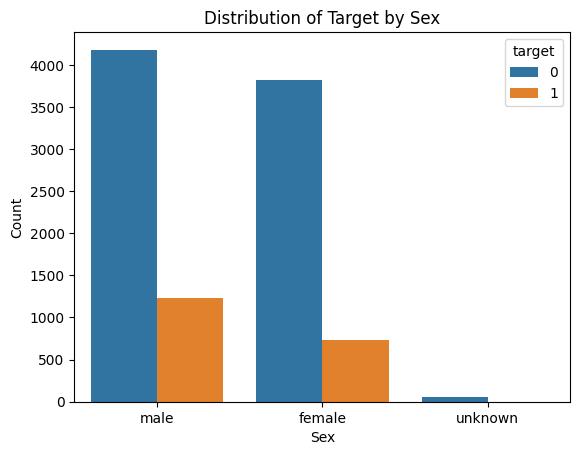

In [252]:
sns.countplot(data=metadata_ham10000, x='sex', hue='target')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Distribution of Target by Sex')
plt.show()

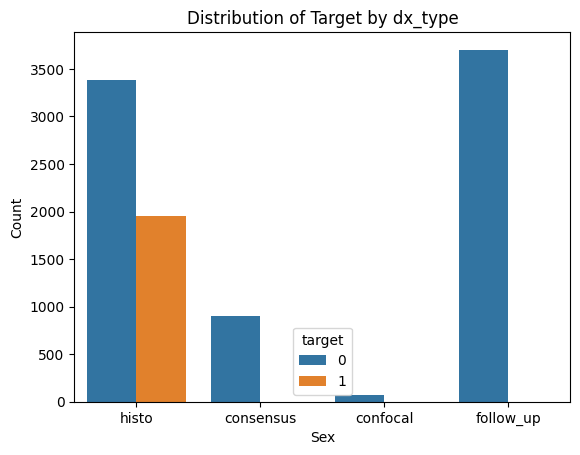

In [253]:
sns.countplot(data=metadata_ham10000, x='dx_type', hue='target')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Distribution of Target by dx_type')
plt.show()

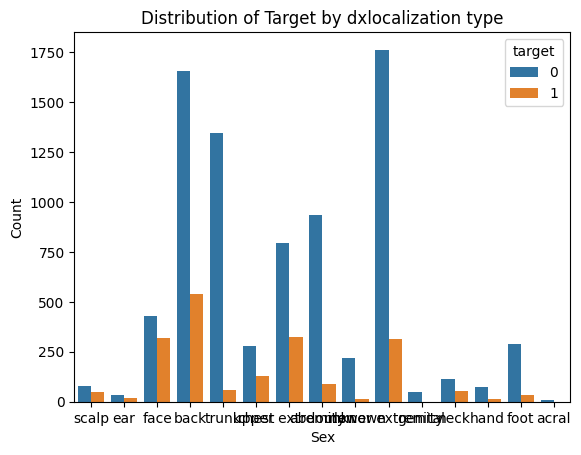

In [254]:
sns.countplot(data=metadata_ham10000, x='localization', hue='target')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Distribution of Target by dxlocalization type')
plt.show()

In [255]:
class HAMDataset(Dataset):
    def __init__(self, df, meta_array, transform=None):
        self.df = df.reset_index(drop=True)
        self.meta_array = meta_array
        self.transform = transform
        self.classes = sorted(self.df['target'].unique())
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['full_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)
        label = self.class_to_idx[row['target']]
        return image, meta_features, label


In [256]:
# 1-hot encoding + scaling
meta_raw = metadata_ham10000[['age', 'sex', 'localization']].copy()
meta_ham10000_encoded = pd.get_dummies(meta_raw, columns=['sex', 'localization'])
scaler = StandardScaler()
meta_ham10000_encoded['age'] = scaler.fit_transform(meta_ham10000_encoded[['age']])

In [257]:
meta_ham10000_encoded = meta_ham10000_encoded.set_index(metadata_ham10000.index)

# Select metadata rows for each split and convert
train_ham10000_meta = torch.tensor(meta_ham10000_encoded.loc[train_ham10000_df.index].to_numpy().astype(np.float32))
val_ham10000_meta   = torch.tensor(meta_ham10000_encoded.loc[val_ham10000_df.index].to_numpy().astype(np.float32))
test_ham10000_meta  = torch.tensor(meta_ham10000_encoded.loc[test_ham10000_df.index].to_numpy().astype(np.float32))

In [258]:
train_dataset_ham10000_metadata = HAMDataset(train_ham10000_df, meta_array=train_ham10000_meta, transform=train_transforms)
val_dataset_ham10000_metadata   = HAMDataset(val_ham10000_df, meta_array=val_ham10000_meta, transform=val_test_transforms)
test_dataset_ham10000_metadata  = HAMDataset(test_ham10000_df, meta_array=test_ham10000_meta, transform=val_test_transforms)

train_loader_ham10000_metadata = DataLoader(train_dataset_ham10000_metadata, batch_size=32, shuffle=True)
val_loader_ham10000_metadata   = DataLoader(val_dataset_ham10000_metadata, batch_size=32, shuffle=False)
test_loader_ham10000_metadata  = DataLoader(test_dataset_ham10000_metadata, batch_size=32, shuffle=False)

In [259]:
class ResNetWithMetadata(nn.Module):
    def __init__(self, num_metadata_features, num_classes, freeze):
        super(ResNetWithMetadata, self).__init__()

        # Load pretrained ResNet101
        self.resnet = models.resnet101(pretrained=True)

        # Replace ResNet's classification head with identity
        self.resnet.fc = nn.Identity()

        # Metadata MLP with BatchNorm
        self.meta_fc = nn.Sequential(
            nn.Linear(num_metadata_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
        )

        # Optional: Gating mechanism to balance image vs metadata features
        self.gate = nn.Sequential(
            nn.Linear(2048 + 32, 1),
            nn.Sigmoid()
        )

        # Final classifier
        self.classifier = nn.Sequential(
            nn.Linear(2048 + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

        # Unfreeze only the classifying blocks for fine-tuning
        if freeze == True:
          for name, param in self.resnet.named_parameters():
              if ("meta_fc" in name) or ("classifier" in name) or ("meta_fc" in name):
                param.requires_grad = True
              else:
                param.requires_grad =  False
        else:
          for name, param in self.resnet.named_parameters():
              param.requires_grad = True

    def forward(self, image, metadata):
        # Extract features
        image_features = self.resnet(image)              # [batch, 2048]
        metadata_features = self.meta_fc(metadata)       # [batch, 32]

        # Concatenate both
        combined = torch.cat((image_features, metadata_features), dim=1)  # [batch, 2080]

        # Apply gating (optional attention-like weighting)
        gate_value = self.gate(combined)                 # [batch, 1]
        combined = gate_value * combined                 # scaled features

        # Final classification
        output = self.classifier(combined)
        return output

In [260]:
def evaluate_model(model, dataloader, device):
    model.eval()
    total = 0
    correct = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, metadata, labels in dataloader:
            images = images.to(device)
            metadata = metadata.to(device)
            labels = labels.to(device)

            outputs = model(images, metadata)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(probs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    print(f"✅ Eval Accuracy: {accuracy:.2f}%")
    return all_preds, all_labels, all_probs

In [261]:
num_metadata_features_ham10000 = train_ham10000_meta.shape[1]
num_classes_ham10000 = len(train_dataset_ham10000_metadata.classes)
model = ResNetWithMetadata(num_metadata_features=num_metadata_features_ham10000,num_classes=num_classes_ham10000, freeze=freeze_resnet).to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [262]:
EPOCHS = 50
save_path = '2_ham10000_pretrained_metadata.pth'
best_f1 = 0
optimizer = optim.Adam(model.parameters(), lr=5e-5)

In [263]:
# training + best model selection on validation data
start_time = time.perf_counter()
for epoch in range(EPOCHS):
    print(f"\n🚀 Epoch {epoch + 1}/{EPOCHS}")
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(train_loader_ham10000_metadata, desc=f"Training Epoch {epoch+1}/{EPOCHS}")

    for images, metadata, labels in loop:
        images = images.to(device)
        metadata = metadata.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, metadata)
        loss = criterion_ham10000(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

    # 🎯 Training summary
    train_loss = running_loss / len(train_loader_ham10000_metadata)
    train_acc = 100 * correct / total
    print(f"✅ Training Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")

    # 🧪 VALIDATION
    val_preds, val_labels, val_probs = evaluate_model(model, val_loader_ham10000_metadata, device)

    f1 = f1_score(val_labels, val_preds)
    auc = roc_auc_score(val_labels, val_probs)
    cm = confusion_matrix(val_labels, val_preds)

    print(f"📊 Validation F1 Score: {f1:.4f}")
    print(f"📈 Validation AUC: {auc:.4f}")
    print(f"🧾 Confusion Matrix:\n{cm}")

    # 💾 Save best model by F1
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), save_path)
        model_ham10000_pretrained_metadata = copy.deepcopy(model)
        print(f"💾 Saved new best model with F1: {best_f1:.4f}")

end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.4f} seconds")


🚀 Epoch 1/50


Training Epoch 1/50:   0%|          | 0/201 [00:00<?, ?it/s]<ipython-input-255-b12b39651b23>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)
Training Epoch 1/50: 100%|██████████| 201/201 [01:25<00:00,  2.36it/s, acc=41.8, loss=0.509]


✅ Training Loss: 0.4928 | Accuracy: 41.82%
✅ Eval Accuracy: 62.51%
📊 Validation F1 Score: 0.5012
📈 Validation AUC: 0.8641
🧾 Confusion Matrix:
[[700 590]
 [ 11 302]]
💾 Saved new best model with F1: 0.5012

🚀 Epoch 2/50


Training Epoch 2/50:   0%|          | 0/201 [00:00<?, ?it/s]<ipython-input-255-b12b39651b23>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)
Training Epoch 2/50: 100%|██████████| 201/201 [01:23<00:00,  2.41it/s, acc=61.6, loss=0.287]


✅ Training Loss: 0.4287 | Accuracy: 61.63%
✅ Eval Accuracy: 61.38%
📊 Validation F1 Score: 0.4939
📈 Validation AUC: 0.8797
🧾 Confusion Matrix:
[[682 608]
 [ 11 302]]

🚀 Epoch 3/50


...

✅ Training Loss: 0.3383 | Accuracy: 69.68%
✅ Eval Accuracy: 63.57%
📊 Validation F1 Score: 0.5109
📈 Validation AUC: 0.9036
🧾 Confusion Matrix:
[[714 576]
 [  8 305]]

🚀 Epoch 49/50


Training Epoch 49/50:   0%|          | 0/201 [00:00<?, ?it/s]<ipython-input-255-b12b39651b23>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)
Training Epoch 49/50: 100%|██████████| 201/201 [01:23<00:00,  2.42it/s, acc=70, loss=0.416]


✅ Training Loss: 0.3296 | Accuracy: 69.98%
✅ Eval Accuracy: 72.11%
📊 Validation F1 Score: 0.5673
📈 Validation AUC: 0.9057
🧾 Confusion Matrix:
[[863 427]
 [ 20 293]]

🚀 Epoch 50/50


Training Epoch 50/50:   0%|          | 0/201 [00:00<?, ?it/s]<ipython-input-255-b12b39651b23>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)
Training Epoch 50/50: 100%|██████████| 201/201 [01:23<00:00,  2.41it/s, acc=69.9, loss=0.242]


✅ Training Loss: 0.3305 | Accuracy: 69.89%
✅ Eval Accuracy: 72.24%
📊 Validation F1 Score: 0.5684
📈 Validation AUC: 0.9081
🧾 Confusion Matrix:
[[865 425]
 [ 20 293]]
Execution time: 5107.2239 seconds


<ipython-input-255-b12b39651b23>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)


✅ Eval Accuracy: 77.13%
📊 Test F1 Score: 0.6059
📈 Test AUC: 0.8889
🧾 Test Confusion Matrix:


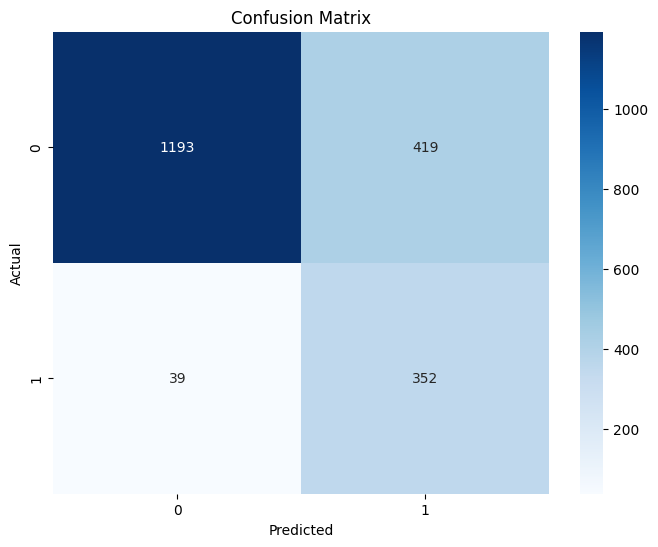

In [264]:
# evaluate on test dataset
test_preds, test_labels, test_probs = evaluate_model(model_ham10000_pretrained_metadata, test_loader_ham10000_metadata, device)
f1 = f1_score(test_labels, test_preds)
auc = roc_auc_score(test_labels, test_probs)
cm = confusion_matrix(test_labels, test_preds)

print(f"📊 Test F1 Score: {f1:.4f}")
print(f"📈 Test AUC: {auc:.4f}")
print(f"🧾 Test Confusion Matrix:")
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_dataset_ham10000_metadata.classes, yticklabels=train_dataset_ham10000_metadata.classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#3. HAM 1000 Analysis: Re-train Resnet - With Metadata

In [265]:
freeze_resnet = False

In [266]:
num_metadata_features_ham10000 = train_ham10000_meta.shape[1]
num_classes_ham10000 = len(train_dataset_ham10000_metadata.classes)
model = ResNetWithMetadata(num_metadata_features=num_metadata_features_ham10000,num_classes=num_classes_ham10000, freeze=freeze_resnet).to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [267]:
EPOCHS = 50
save_path = '3_ham10000_retrained_metadata.pth'
best_f1 = 0
optimizer = optim.Adam(model.parameters(), lr=5e-5)

In [268]:
# training + best model selection on validation data
start_time = time.perf_counter()
for epoch in range(EPOCHS):
    print(f"\n🚀 Epoch {epoch + 1}/{EPOCHS}")
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(train_loader_ham10000_metadata, desc=f"Training Epoch {epoch+1}/{EPOCHS}")

    for images, metadata, labels in loop:
        images = images.to(device)
        metadata = metadata.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, metadata)
        loss = criterion_ham10000(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

    # 🎯 Training summary
    train_loss = running_loss / len(train_loader_ham10000_metadata)
    train_acc = 100 * correct / total
    print(f"✅ Training Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")

    # 🧪 VALIDATION
    val_preds, val_labels, val_probs = evaluate_model(model, val_loader_ham10000_metadata, device)

    f1 = f1_score(val_labels, val_preds)
    auc = roc_auc_score(val_labels, val_probs)
    cm = confusion_matrix(val_labels, val_preds)

    print(f"📊 Validation F1 Score: {f1:.4f}")
    print(f"📈 Validation AUC: {auc:.4f}")
    print(f"🧾 Confusion Matrix:\n{cm}")

    # 💾 Save best model by F1
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), save_path)
        model_ham10000_retrained_metadata = copy.deepcopy(model)
        print(f"💾 Saved new best model with F1: {best_f1:.4f}")

end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.4f} seconds")


🚀 Epoch 1/50


Training Epoch 1/50:   0%|          | 0/201 [00:00<?, ?it/s]<ipython-input-255-b12b39651b23>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)
Training Epoch 1/50: 100%|██████████| 201/201 [01:33<00:00,  2.15it/s, acc=57.1, loss=0.223]


✅ Training Loss: 0.4060 | Accuracy: 57.09%
✅ Eval Accuracy: 79.41%
📊 Validation F1 Score: 0.6284
📈 Validation AUC: 0.9123
🧾 Confusion Matrix:
[[994 296]
 [ 34 279]]
💾 Saved new best model with F1: 0.6284

🚀 Epoch 2/50


Training Epoch 2/50:   0%|          | 0/201 [00:00<?, ?it/s]<ipython-input-255-b12b39651b23>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)
Training Epoch 2/50: 100%|██████████| 201/201 [01:35<00:00,  2.11it/s, acc=67, loss=0.44]


✅ Training Loss: 0.3459 | Accuracy: 67.00%
✅ Eval Accuracy: 80.60%
📊 Validation F1 Score: 0.6446
📈 Validation AUC: 0.9201
🧾 Confusion Matrix:
[[1010  280]
 [  31  282]]
💾 Saved new best model with F1: 0.6446

🚀 Epoch 3/50


...

✅ Training Loss: 0.1395 | Accuracy: 89.80%
✅ Eval Accuracy: 88.90%
📊 Validation F1 Score: 0.7443
📈 Validation AUC: 0.9393
🧾 Confusion Matrix:
[[1166  124]
 [  54  259]]

🚀 Epoch 49/50


Training Epoch 49/50:   0%|          | 0/201 [00:00<?, ?it/s]<ipython-input-255-b12b39651b23>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)
Training Epoch 49/50: 100%|██████████| 201/201 [01:26<00:00,  2.32it/s, acc=90.4, loss=0.0952]


✅ Training Loss: 0.1297 | Accuracy: 90.42%
✅ Eval Accuracy: 88.52%
📊 Validation F1 Score: 0.7341
📈 Validation AUC: 0.9434
🧾 Confusion Matrix:
[[1165  125]
 [  59  254]]

🚀 Epoch 50/50


Training Epoch 50/50:   0%|          | 0/201 [00:00<?, ?it/s]<ipython-input-255-b12b39651b23>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)
Training Epoch 50/50: 100%|██████████| 201/201 [01:26<00:00,  2.33it/s, acc=89.8, loss=0.133]


✅ Training Loss: 0.1416 | Accuracy: 89.80%
✅ Eval Accuracy: 89.02%
📊 Validation F1 Score: 0.7507
📈 Validation AUC: 0.9462
🧾 Confusion Matrix:
[[1162  128]
 [  48  265]]
Execution time: 5355.5212 seconds


<ipython-input-255-b12b39651b23>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)


✅ Eval Accuracy: 89.47%
📊 Test F1 Score: 0.7332
📈 Test AUC: 0.9371
🧾 Test Confusion Matrix:


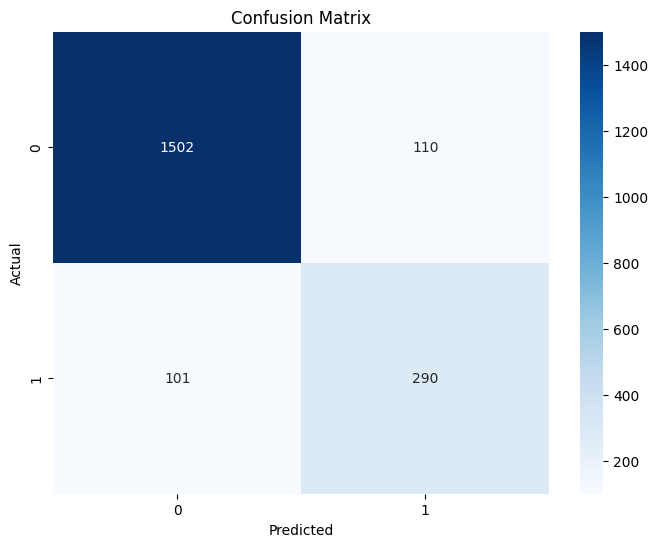

In [269]:
# evaluate on test dataset
test_preds, test_labels, test_probs = evaluate_model(model_ham10000_retrained_metadata, test_loader_ham10000_metadata, device)
f1 = f1_score(test_labels, test_preds)
auc = roc_auc_score(test_labels, test_probs)
cm = confusion_matrix(test_labels, test_preds)

print(f"📊 Test F1 Score: {f1:.4f}")
print(f"📈 Test AUC: {auc:.4f}")
print(f"🧾 Test Confusion Matrix:")
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_dataset_ham10000_metadata.classes, yticklabels=train_dataset_ham10000_metadata.classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#4. HAM 1000 Analysis: Re-train Resnet - With Metadata - Minority Class Augmentation

In [270]:
# key parameters
freeze_resnet = False
class_to_augment = 1
augment_factor = int(class_ratio_ham10000)-1

In [271]:
class synthetic_images_generation_ham10000():
  def __init__(self, class_to_augment, augment_factor, out_path, metadata_out_path):
    self.class_to_augment = class_to_augment
    self.augment_factor = int(augment_factor)
    self.out_path = out_path
    self.metadata_out_path = metadata_out_path

  def augment(self, metadata):
    # metadata_augment_df = pd.DataFrame(columns=metadata.columns)
    # print(metadata_augment_df.head())
    rows = []

    for index,row in metadata.iterrows():
      # print(row)
      image = Image.open(row['full_path']).convert('RGB')

      if row['target'] == self.class_to_augment:
        for i in range(self.augment_factor):
            transformed_image = train_transforms(image)

            # print(transformed_image)
            transformed_image_name = row['image_path'].split(".")[0] + '_' + str(i) + '.jpg'
            row_aug = row.copy()
            row_aug['image_path'] = transformed_image_name
            row_aug['full_path'] = self.out_path + transformed_image_name
            rows.append(row_aug)

            transformed_image_np = transformed_image.numpy(force=True)
            transformed_image_np = 255*transformed_image_np
            transformed_image_np = transformed_image_np.astype(np.uint8)
            transformed_image_np = np.transpose(transformed_image_np, (1, 2, 0))
            # image = cv2.cvtColor(cv2.imdecode(image, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
            # print(transformed_image_np.shape)
            # print(transformed_image_np)
            transformed_image_np = Image.fromarray(transformed_image_np)
            transformed_image_np.save(row_aug['full_path'])
      else:
        # metadata_augment_df = pd.concat([metadata_augment_df, row.to_frame()], axis=0)
        transformed_image = train_transforms(image)

        transformed_image_name = row['image_path']
        row_aug = row.copy()
        row_aug['image_path'] = transformed_image_name
        row_aug['full_path'] = self.out_path + transformed_image_name
        rows.append(row_aug)

        transformed_image_np = transformed_image.numpy(force=True)
        transformed_image_np = 255*transformed_image_np
        transformed_image_np = transformed_image_np.astype(np.uint8)
        transformed_image_np = np.transpose(transformed_image_np, (1, 2, 0))
        # image = cv2.cvtColor(cv2.imdecode(image, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
        # print(transformed_image_np.shape)
        # print(transformed_image_np)
        transformed_image_np = Image.fromarray(transformed_image_np)
        transformed_image_np.save(row_aug['full_path'])

    pd.DataFrame(rows).to_csv(self.metadata_out_path, index=False)

In [272]:
# initialize synthetic data generation class
out_path = r"MNIST-HAM10000/HAM10000-augmented/"
metadata_out_path = r"MNIST-HAM10000/HAM10000_metadata_augmented.csv"
# metadata_isic_debug = metadata_isic[metadata_isic['target']==1].head(1) # for debug
os.makedirs(out_path, exist_ok=True)

synthetic_images_ham10000 = synthetic_images_generation_ham10000(class_to_augment=class_to_augment, augment_factor=augment_factor, out_path=out_path, metadata_out_path=metadata_out_path)

In [273]:
# this can only be ran once if you don't want to re-generate a new set of training data
synthetic_images_ham10000.augment(metadata_ham10000)

In [274]:
metadata_ham10000_augmented = pd.read_csv(r"MNIST-HAM10000/HAM10000_metadata_augmented.csv")
# binary_map = {
#     "nv": "benign",
#     "bkl":"benign",
#     "df": "benign",
#     "vasc": "benign",
#     "mel": "Not Benign",
#     "bcc":  "Not Benign",
#     "akiec":  "Not Benign"
# }

binary_map = {
    "nv": 0,
    "bkl": 0,
    "df": 0,
    "vasc": 0,
    "mel": 1,
    "bcc":  1,
    "akiec": 1
}

metadata_ham10000_augmented["target"] = metadata_ham10000_augmented["dx"].map(binary_map)
# print(metadata.target.unique())

In [275]:
lesion_counts = metadata_ham10000_augmented['lesion_id'].value_counts()
metadata_ham10000_augmented['duplicates'] = metadata_ham10000_augmented['lesion_id'].map(lambda x: 'duplicated' if lesion_counts[x] > 1 else 'unduplicated')
metadata_ham10000_augmented['age'] = metadata_ham10000_augmented['age'].fillna(metadata_ham10000_augmented['age'].median())
metadata_ham10000_augmented['sex'] = metadata_ham10000_augmented['sex'].fillna('unknown')
metadata_ham10000_augmented['localization'] = metadata_ham10000_augmented['localization'].fillna('unknown')
# metadata_ham10000_augmented = metadata_ham10000_augmented.groupby('lesion_id').sample(n=1, random_state=42).reset_index(drop=True)

In [276]:
train_val_ham10000_augmented_df, test_ham10000_augmented_df = train_test_split(metadata_ham10000_augmented, test_size=0.2, stratify=metadata_ham10000_augmented['target'], random_state=42)
train_ham10000_augmented_df, val_ham10000_augmented_df = train_test_split(train_val_ham10000_augmented_df, test_size=0.2, stratify=train_val_ham10000_augmented_df['target'], random_state=42)

In [277]:
# 1-hot encoding + scaling
meta_raw = metadata_ham10000_augmented[['age', 'sex', 'localization']].copy()
meta_ham10000_augmented_encoded = pd.get_dummies(meta_raw, columns=['sex', 'localization'])
scaler = StandardScaler()
meta_ham10000_augmented_encoded['age'] = scaler.fit_transform(meta_ham10000_augmented_encoded[['age']])

In [278]:
meta_ham10000_augmented_encoded = meta_ham10000_augmented_encoded.set_index(metadata_ham10000_augmented.index)

# Select metadata rows for each split and convert
train_ham10000_augmented_meta = torch.tensor(meta_ham10000_augmented_encoded.loc[train_ham10000_augmented_df.index].to_numpy().astype(np.float32))
val_ham10000_augmented_meta   = torch.tensor(meta_ham10000_augmented_encoded.loc[val_ham10000_augmented_df.index].to_numpy().astype(np.float32))
test_ham10000_augmented_meta  = torch.tensor(meta_ham10000_augmented_encoded.loc[test_ham10000_augmented_df.index].to_numpy().astype(np.float32))

In [279]:
train_dataset_ham10000_augmented_metadata = HAMDataset(train_ham10000_augmented_df, meta_array=train_ham10000_augmented_meta, transform=train_transforms)
val_dataset_ham10000_augmented_metadata   = HAMDataset(val_ham10000_augmented_df, meta_array=val_ham10000_augmented_meta, transform=val_test_transforms)
test_dataset_ham10000_augmented_metadata  = HAMDataset(test_ham10000_augmented_df, meta_array=test_ham10000_augmented_meta, transform=val_test_transforms)

train_loader_ham10000_augmented_metadata = DataLoader(train_dataset_ham10000_augmented_metadata, batch_size=32, shuffle=True)
val_loader_ham10000_augmented_metadata   = DataLoader(val_dataset_ham10000_augmented_metadata, batch_size=32, shuffle=False)
test_loader_ham10000_augmented_metadata  = DataLoader(test_dataset_ham10000_augmented_metadata, batch_size=32, shuffle=False)

In [280]:
num_metadata_features_ham10000_augmented = train_ham10000_augmented_meta.shape[1]
num_classes_ham10000_augmented = len(train_dataset_ham10000_augmented_metadata.classes)
model = ResNetWithMetadata(num_metadata_features=num_metadata_features_ham10000_augmented,num_classes=num_classes_ham10000_augmented, freeze=freeze_resnet).to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [281]:
# loss function seetings
class_count_ham10000_augmented = metadata_ham10000_augmented['target'].value_counts()
class_ratio_ham10000_augmented = class_count_ham10000_augmented[0]/class_count_ham10000_augmented[1]*0.8
class_weights_ham10000_augmented = torch.tensor([1.0, class_ratio_ham10000_augmented], dtype=torch.float32).to(device)
criterion_ham10000_augmented = FocalLoss(alpha=class_weights_ham10000_augmented, gamma=2).to(device)

In [282]:
EPOCHS = 50
save_path = '4_ham10000_retrained_metadata_augmented.pth'
best_f1 = 0
optimizer = optim.Adam(model.parameters(), lr=5e-5)

In [283]:
# training + best model selection on validation data
start_time = time.perf_counter()
for epoch in range(EPOCHS):
    print(f"\n🚀 Epoch {epoch + 1}/{EPOCHS}")
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(train_loader_ham10000_augmented_metadata, desc=f"Training Epoch {epoch+1}/{EPOCHS}")

    for images, metadata, labels in loop:
        images = images.to(device)
        metadata = metadata.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, metadata)
        loss = criterion_ham10000_augmented(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

    # 🎯 Training summary
    train_loss = running_loss / len(train_loader_ham10000_augmented_metadata)
    train_acc = 100 * correct / total
    print(f"✅ Training Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")

    # 🧪 VALIDATION
    val_preds, val_labels, val_probs = evaluate_model(model, val_loader_ham10000_augmented_metadata, device)

    f1 = f1_score(val_labels, val_preds)
    auc = roc_auc_score(val_labels, val_probs)
    cm = confusion_matrix(val_labels, val_preds)

    print(f"📊 Validation F1 Score: {f1:.4f}")
    print(f"📈 Validation AUC: {auc:.4f}")
    print(f"🧾 Confusion Matrix:\n{cm}")

    # 💾 Save best model by F1
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), save_path)
        model_ham10000_pretrained_metadata_augmented = copy.deepcopy(model)
        print(f"💾 Saved new best model with F1: {best_f1:.4f}")

end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.4f} seconds")


🚀 Epoch 1/50


Training Epoch 1/50:   0%|          | 0/279 [00:00<?, ?it/s]<ipython-input-255-b12b39651b23>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)
Training Epoch 1/50: 100%|██████████| 279/279 [00:55<00:00,  5.03it/s, acc=73.1, loss=0.184]


✅ Training Loss: 0.1440 | Accuracy: 73.14%
✅ Eval Accuracy: 78.55%
📊 Validation F1 Score: 0.7436
📈 Validation AUC: 0.8606
🧾 Confusion Matrix:
[[1057  233]
 [ 245  693]]
💾 Saved new best model with F1: 0.7436

🚀 Epoch 2/50


Training Epoch 2/50:   0%|          | 0/279 [00:00<?, ?it/s]<ipython-input-255-b12b39651b23>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)
Training Epoch 2/50: 100%|██████████| 279/279 [00:55<00:00,  5.01it/s, acc=76.3, loss=0.1]


✅ Training Loss: 0.1336 | Accuracy: 76.34%
✅ Eval Accuracy: 80.07%
📊 Validation F1 Score: 0.7582
📈 Validation AUC: 0.8887
🧾 Confusion Matrix:
[[1088  202]
 [ 242  696]]
💾 Saved new best model with F1: 0.7582

🚀 Epoch 3/50


...

✅ Training Loss: 0.0682 | Accuracy: 90.28%
✅ Eval Accuracy: 86.89%
📊 Validation F1 Score: 0.8507
📈 Validation AUC: 0.9450
🧾 Confusion Matrix:
[[1104  186]
 [ 106  832]]

🚀 Epoch 49/50


Training Epoch 49/50:   0%|          | 0/279 [00:00<?, ?it/s]<ipython-input-255-b12b39651b23>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)
Training Epoch 49/50: 100%|██████████| 279/279 [00:53<00:00,  5.22it/s, acc=89.9, loss=0.0427]


✅ Training Loss: 0.0669 | Accuracy: 89.93%
✅ Eval Accuracy: 87.34%
📊 Validation F1 Score: 0.8437
📈 Validation AUC: 0.9486
🧾 Confusion Matrix:
[[1185  105]
 [ 177  761]]

🚀 Epoch 50/50


Training Epoch 50/50:   0%|          | 0/279 [00:00<?, ?it/s]<ipython-input-255-b12b39651b23>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)
Training Epoch 50/50: 100%|██████████| 279/279 [00:53<00:00,  5.22it/s, acc=90.1, loss=0.0275]


✅ Training Loss: 0.0640 | Accuracy: 90.08%
✅ Eval Accuracy: 87.97%
📊 Validation F1 Score: 0.8588
📈 Validation AUC: 0.9511
🧾 Confusion Matrix:
[[1145  145]
 [ 123  815]]
Execution time: 3034.0327 seconds


<ipython-input-255-b12b39651b23>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)


✅ Eval Accuracy: 86.22%
📊 Test F1 Score: 0.7064
📈 Test AUC: 0.9412
🧾 Test Confusion Matrix:


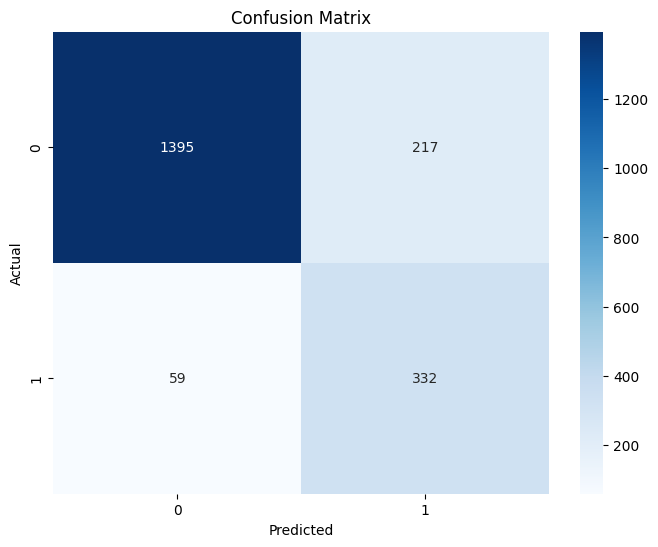

In [284]:
# evaluate on test dataset
test_preds, test_labels, test_probs = evaluate_model(model_ham10000_pretrained_metadata_augmented, test_loader_ham10000_metadata, device)
f1 = f1_score(test_labels, test_preds)
auc = roc_auc_score(test_labels, test_probs)
cm = confusion_matrix(test_labels, test_preds)

print(f"📊 Test F1 Score: {f1:.4f}")
print(f"📈 Test AUC: {auc:.4f}")
print(f"🧾 Test Confusion Matrix:")
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_dataset_ham10000_metadata.classes, yticklabels=train_dataset_ham10000_metadata.classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#5. ISIC 2024 Analysis: Retrain - With Metadata

In [285]:
# weights from pre-trained model
weights_path = '3_ham10000_retrained_metadata.pth'
freeze_resnet = False

# benign cases sub-sample fraction (this is to reduce training time)
benign_subsample = 0.02

# hdf5 file path
hdf5_path = r"isic-2024-challenge/train-image.hdf5"

# load metadata and map localization column categories
metadata_isic = pd.read_csv(r"isic-2024-challenge/train-metadata.csv")
metadata_isic = metadata_isic[['isic_id', 'patient_id', 'target', 'sex', 'age_approx', 'anatom_site_general']]
metadata_isic.rename(columns = {'age_approx':'age', 'anatom_site_general':'localization'}, inplace=True)
localization_map = {
    "posterior torso": "back",
    "lower extremity":"lower extremity",
    "anterior torso": "trunk",
    "upper extremity": "upper extremity",
    "head/neck": "face"
}

metadata_isic["localization"] = metadata_isic["localization"].map(localization_map)

# remove where metadata not available (we still have a lot of data to train on)
metadata_isic = metadata_isic[~(pd.isnull(metadata_isic['localization']))]
metadata_isic = metadata_isic[~(pd.isnull(metadata_isic['sex']))]
metadata_isic = metadata_isic[~(pd.isnull(metadata_isic['age']))]

# add image data path
base_dir = r"isic-2024-challenge/train-image/image/"
metadata_isic['image_path'] = metadata_isic['isic_id']
metadata_isic['full_path'] = (metadata_isic['image_path'])

# reduce number of rows to keep traiining time reasonale
# meta_isic_encoded = meta_isic_encoded.sample(frac=0.1, random_state=42)
metadata_isic_0 = metadata_isic[metadata_isic['target']==0]
metadata_isic_0 = metadata_isic_0.sample(frac=benign_subsample, random_state=42)
metadata_isic_1 = metadata_isic[metadata_isic['target']==1]
metadata_isic = pd.concat([metadata_isic_0, metadata_isic_1], ignore_index=True)
metadata_isic = metadata_isic.reset_index(drop=True)

# split in training, validation and test and convert to tensor
train_val_isic_df, test_isic_df = train_test_split(metadata_isic, test_size=0.2, stratify=metadata_isic['target'], random_state=42)
train_isic_df, val_isic_df = train_test_split(train_val_isic_df, test_size=0.2, stratify=train_val_isic_df['target'], random_state=42)

<ipython-input-285-b864aab9ecbc>:12: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata_isic = pd.read_csv(r"isic-2024-challenge/train-metadata.csv")


In [286]:
# 1-hot encoding + age scaling
meta_raw = metadata_isic[['age', 'sex', 'localization']].copy()
meta_isic_encoded = pd.get_dummies(meta_raw, columns=['sex', 'localization'])
meta_isic_encoded['age'] = scaler.transform(meta_isic_encoded[['age']]) # using same scaler defined on HAM10000 metadata

# no need to do this: the number of meta-features will be different on this dataset and we will fine tune on those
# meta_isic_encoded['sex_unknown'] = False
# meta_isic_cols = [c for c in list(meta_isic_encoded.columns) if 'localization' in c]
# meta_ham_cols = [c for c in list(meta_encoded.columns) if 'localization' in c]
# for c in meta_ham_cols:     # add 1-hot encoded columns not present in new dataset
#   if c not in meta_isic_cols:
#     meta_isic_encoded[c] = False

meta_isic_encoded = meta_isic_encoded.set_index(metadata_isic.index)

In [287]:
# Select metadata rows for each split and convert
train_isic_meta = torch.tensor(meta_isic_encoded.loc[train_isic_df.index].to_numpy().astype(np.float32))
val_isic_meta   = torch.tensor(meta_isic_encoded.loc[val_isic_df.index].to_numpy().astype(np.float32))
test_isic_meta  = torch.tensor(meta_isic_encoded.loc[test_isic_df.index].to_numpy().astype(np.float32))

In [288]:
# Select metadata rows for each split and convert
train_isic_meta = torch.tensor(meta_isic_encoded.loc[train_isic_df.index].to_numpy().astype(np.float32))
val_isic_meta   = torch.tensor(meta_isic_encoded.loc[val_isic_df.index].to_numpy().astype(np.float32))
test_isic_meta  = torch.tensor(meta_isic_encoded.loc[test_isic_df.index].to_numpy().astype(np.float32))

In [289]:
class ISICDataset(Dataset):
    def __init__(self, df, meta_array, hdf5_path, transform=None):
        self.df = df.reset_index(drop=True)
        self.meta_array = meta_array
        self.transform = transform
        self.hdf5_path = hdf5_path
        self.classes = sorted(self.df['target'].unique())
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # image = Image.open(row['full_path']).convert('RGB')
        with h5py.File(self.hdf5_path, 'r') as hf:
            image = hf[row['full_path']][()]
            # Convert the binary data to a numpy array
            image = np.frombuffer(image, np.uint8)
            image = cv2.cvtColor(cv2.imdecode(image, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
            image = Image.fromarray(image)

        if self.transform:
            image = self.transform(image)
        meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)
        label = self.class_to_idx[row['target']]
        return image, meta_features, label

In [290]:
train_dataset_isic = ISICDataset(train_isic_df, meta_array=train_isic_meta, transform=train_transforms, hdf5_path=hdf5_path)
val_dataset_isic   = ISICDataset(val_isic_df, meta_array=val_isic_meta, transform=val_test_transforms, hdf5_path=hdf5_path)
test_dataset_isic  = ISICDataset(test_isic_df, meta_array=test_isic_meta, transform=val_test_transforms, hdf5_path=hdf5_path)

train_loader_isic = DataLoader(train_dataset_isic, batch_size=32, shuffle=True)
val_loader_isic   = DataLoader(val_dataset_isic, batch_size=32, shuffle=False)
test_loader_isic  = DataLoader(test_dataset_isic, batch_size=32, shuffle=False)

In [291]:
class ResNetWithMetadata_FineTune(nn.Module):
    def __init__(self, num_metadata_features, num_classes, freeze, weights_path):
        super(ResNetWithMetadata_FineTune, self).__init__()

        # Load empty ResNet101
        # self.resnet = models.resnet101(pretrained=False)
        self.resnetwithmetadata = ResNetWithMetadata(num_metadata_features=num_metadata_features,num_classes=num_classes, freeze=True)

        # load weights from full training
        self.teacher_dict = torch.load(weights_path)

        # need to remove the meta_fc layer since input size different than teacher model
        self.filtered_state = {k: v for k, v in self.teacher_dict.items() if 'resnet' in k}

        self.resnet_state = self.resnetwithmetadata.resnet.state_dict()
        self.resnet_state.update(self.filtered_state)

        # # Replace ResNet's classification head with identity
        # self.resnetwithmetadata.resnet.fc = nn.Identity()

        # Metadata MLP with BatchNorm
        self.resnetwithmetadata.meta_fc = nn.Sequential(
            nn.Linear(num_metadata_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
        )

        # # Optional: Gating mechanism to balance image vs metadata features
        # self.resnetwithmetadata.gate = nn.Sequential(
        #     nn.Linear(2048 + 32, 1),
        #     nn.Sigmoid()
        # )

        # # Final classifier
        # self.resnetwithmetadata.classifier = nn.Sequential(
        #     nn.Linear(2048 + 32, 128),
        #     nn.ReLU(),
        #     nn.Dropout(0.5),
        #     nn.Linear(128, num_classes)
        # )

        # Unfreeze only the classifying blocks for fine-tuning
        if freeze == True:
          for name, param in self.resnetwithmetadata.named_parameters():
              if ("meta_fc" in name) or ("classifier" in name) or ("gate" in name):
                param.requires_grad = True
              else:
                param.requires_grad =  False
        else:
          for name, param in self.resnetwithmetadata.named_parameters():
              param.requires_grad = True

    def forward(self, image, metadata):
        # Extract features
        image_features = self.resnetwithmetadata.resnet(image)              # [batch, 2048]
        metadata_features = self.resnetwithmetadata.meta_fc(metadata)       # [batch, 32]
        # print('image_features = ' + str(image_features))
        # print('metadata = ' + str(metadata))
        # print('metadata_features = ' + str(metadata_features))

        # Concatenate both
        combined = torch.cat((image_features, metadata_features), dim=1)  # [batch, 2080]
        # print('combined = ' + str(combined))

        # Apply gating (optional attention-like weighting)
        gate_value = self.resnetwithmetadata.gate(combined)                 # [batch, 1]
        combined = gate_value * combined                 # scaled features
        # print('gate value = ' + str(gate_value))


        # Final classification
        output = self.resnetwithmetadata.classifier(combined)
        # print('output = ' + str(output))
        return output

In [292]:
class_count_isic = metadata_isic['target'].value_counts()
class_ratio_isic = class_count_isic[0]/class_count_isic[1]*0.8
# class_ratio = 10
class_weights_isic = torch.tensor([1.0, class_ratio_isic], dtype=torch.float32).to(device)
criterion_isic = FocalLoss(alpha=class_weights_isic, gamma=2).to(device)

In [293]:
num_metadata_features_isic = train_isic_meta.shape[1]
num_classes_isic = len(train_dataset_isic.classes)
model_isic = ResNetWithMetadata_FineTune(num_metadata_features=num_metadata_features_isic,num_classes=num_classes_isic, freeze=freeze_resnet, weights_path = weights_path).to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [294]:
EPOCHS = 50
save_path = '5_isic_retrained_metadata.pth'
best_f1 = 0
optimizer = optim.Adam(model.parameters(), lr=5e-5)

In [ ]:
# training + best model selection on validation data
start_time = time.perf_counter()
for epoch in range(EPOCHS):
    print(f"\n🚀 Epoch {epoch + 1}/{EPOCHS}")
    model_isic.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(train_loader_isic, desc=f"Training Epoch {epoch+1}/{EPOCHS}")

    for images, metadata, labels in loop:
        images = images.to(device)
        metadata = metadata.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model_isic(images, metadata)
        loss = criterion_isic(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

    # 🎯 Training summary
    train_loss = running_loss / len(train_loader_isic)
    train_acc = 100 * correct / total
    print(f"✅ Training Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")

    # 🧪 VALIDATION
    val_preds, val_labels, val_probs = evaluate_model(model_isic, val_loader_isic, device)
    # print(val_preds)
    # print(val_labels)
    # print(val_probs)

    f1 = f1_score(val_labels, val_preds)
    auc = roc_auc_score(val_labels, val_probs)
    cm = confusion_matrix(val_labels, val_preds)

    print(f"📊 Validation F1 Score: {f1:.4f}")
    print(f"📈 Validation AUC: {auc:.4f}")
    print(f"🧾 Confusion Matrix:\n{cm}")

    # 💾 Save best model by F1
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model_isic.state_dict(), save_path)
        model_isic_retrained_metadata = copy.deepcopy(model_isic)
        print(f"💾 Saved new best model with F1: {best_f1:.4f}")

end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.4f} seconds")


🚀 Epoch 1/50


Training Epoch 1/50:   0%|          | 0/161 [00:00<?, ?it/s]<ipython-input-289-cc415b368c7d>:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)
Training Epoch 1/50:  15%|█▍        | 24/161 [01:52<06:05,  2.67s/it, acc=79.5, loss=1.7]  

In [ ]:
# evaluate on test dataset
test_preds, test_labels, test_probs = evaluate_model(model_isic_retrained_metadata, test_loader_isic, device)
f1 = f1_score(test_labels, test_preds)
auc = roc_auc_score(test_labels, test_probs)
cm = confusion_matrix(test_labels, test_preds)

print(f"📊 Test F1 Score: {f1:.4f}")
print(f"📈 Test AUC: {auc:.4f}")
print(f"🧾 Test Confusion Matrix:")
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_dataset_isic.classes, yticklabels=train_dataset_isic.classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#6. ISIC 2024 Analysis: Transfer Learning from ResNet trained on HAM10000 - With Metadata

In [ ]:
# weights from pre-trained model
weights_path = '3_ham10000_retrained_metadata.pth'
freeze_resnet = True

In [ ]:
num_metadata_features_isic = train_isic_meta.shape[1]
num_classes_isic = len(train_dataset_isic.classes)
model_isic = ResNetWithMetadata_FineTune(num_metadata_features=num_metadata_features_isic,num_classes=num_classes_isic, freeze=freeze_resnet, weights_path = weights_path).to(device)

In [ ]:
EPOCHS = 50
save_path = '6_isic_pretrained_metadata.pth'
best_f1 = 0
optimizer = optim.Adam(model.parameters(), lr=5e-5)

In [ ]:
start_time = time.perf_counter()
for epoch in range(EPOCHS):
    print(f"\n🚀 Epoch {epoch + 1}/{EPOCHS}")
    model_isic.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(train_loader_isic, desc=f"Training Epoch {epoch+1}/{EPOCHS}")

    for images, metadata, labels in loop:
        images = images.to(device)
        metadata = metadata.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model_isic(images, metadata)
        loss = criterion_isic(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

    # 🎯 Training summary
    train_loss = running_loss / len(train_loader_isic)
    train_acc = 100 * correct / total
    print(f"✅ Training Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")

    # 🧪 VALIDATION
    val_preds, val_labels, val_probs = evaluate_model(model_isic, val_loader_isic, device)
    # print(val_preds)
    # print(val_labels)
    # print(val_probs)

    f1 = f1_score(val_labels, val_preds)
    auc = roc_auc_score(val_labels, val_probs)
    cm = confusion_matrix(val_labels, val_preds)

    print(f"📊 Validation F1 Score: {f1:.4f}")
    print(f"📈 Validation AUC: {auc:.4f}")
    print(f"🧾 Confusion Matrix:\n{cm}")

    # 💾 Save best model by F1
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model_isic.state_dict(), save_path)
        model_isic_pretrained_metadata = copy.deepcopy(model_isic)
        print(f"💾 Saved new best model with F1: {best_f1:.4f}")

end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.4f} seconds")

In [ ]:
# evaluate on test dataset
test_preds, test_labels, test_probs = evaluate_model(model_isic_pretrained_metadata, test_loader_isic, device)
f1 = f1_score(test_labels, test_preds)
auc = roc_auc_score(test_labels, test_probs)
cm = confusion_matrix(test_labels, test_preds)

print(f"📊 Test F1 Score: {f1:.4f}")
print(f"📈 Test AUC: {auc:.4f}")
print(f"🧾 Test Confusion Matrix:")
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_dataset_isic.classes, yticklabels=train_dataset_isic.classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#7. ISIC 2024 Analysis: Transfer Learning from ResNet trained on HAM10000 - With Metadata - Minority Class Augmentation

In [ ]:
# key parameters
weights_path = '3_ham10000_retrained_metadata.pth'
freeze_resnet = True
class_to_augment = 1
augment_factor = 9

In [ ]:
class synthetic_images_generation_isic():
  def __init__(self, hdf5_path, class_to_augment, augment_factor, hdf5_out_path, metadata_out_path):
    self.hdf5_path = hdf5_path
    self.class_to_augment = class_to_augment
    self.augment_factor = int(augment_factor)
    self.hdf5_out_path = hdf5_out_path
    self.metadata_out_path = metadata_out_path

  def augment(self, metadata):
    # metadata_augment_df = pd.DataFrame(columns=metadata.columns)
    # print(metadata_augment_df.head())
    rows = []

    with h5py.File(self.hdf5_out_path, 'w') as hf_out:
      with h5py.File(self.hdf5_path, 'r') as hf:
        for index,row in metadata.iterrows():
          # print(row)
          image = hf[row['full_path']][()]
          # Convert the binary data to a numpy array
          image = np.frombuffer(image, np.uint8)
          image = cv2.cvtColor(cv2.imdecode(image, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
          image = Image.fromarray(image)
          # print(image)

          if row['target'] == self.class_to_augment:
            for i in range(self.augment_factor):
                transformed_image = train_transforms(image)

                # print(transformed_image)
                transformed_image_name = row['full_path'] + '_' + str(i)

                row_aug = row.copy()
                row_aug['image_path'] = transformed_image_name
                row_aug['full_path'] = transformed_image_name

                # metadata_augment_df = pd.concat([metadata_augment_df, row_aug.to_frame()], axis=0)
                rows.append(row_aug)

                with h5py.File(self.hdf5_out_path, 'a') as hf_out:
                  hf_out.create_dataset(transformed_image_name, data=transformed_image)
          else:
            # metadata_augment_df = pd.concat([metadata_augment_df, row.to_frame()], axis=0)
            rows.append(row)
            transformed_image = train_transforms(image)
            with h5py.File(self.hdf5_out_path, 'a') as hf_out:
              hf_out.create_dataset(row['full_path'], data=transformed_image)

        # print(metadata_augment_df.head())

    pd.DataFrame(rows).to_csv(self.metadata_out_path, index=False)

In [ ]:
# initialize synthetic data generation class
hdf5_path = r"isic-2024-challenge/train-image.hdf5"
hdf5_out_augmented = r"isic-2024-challenge/train-image-augmented.hdf5"
metadata_out_path = r"isic-2024-challenge/train-metadata-augmented.csv"
# metadata_isic_debug = metadata_isic[metadata_isic['target']==1].head(1) # for debug

synthetic_images_isic = synthetic_images_generation_isic(hdf5_path=hdf5_path, class_to_augment=class_to_augment, augment_factor=augment_factor, hdf5_out_path=hdf5_out_augmented, metadata_out_path=metadata_out_path)

In [ ]:
# this can only be ran once if you don't want to re-generate a new set of training data
synthetic_images_isic.augment(metadata_isic)

In [ ]:
class AugmentedISICDataset(Dataset):
    def __init__(self, df, meta_array, hdf5_path, transform=None):
        self.df = df.reset_index(drop=True)
        self.meta_array = meta_array
        self.transform = transform
        self.hdf5_path = hdf5_path
        self.classes = sorted(self.df['target'].unique())
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # image = Image.open(row['full_path']).convert('RGB')
        with h5py.File(self.hdf5_path, 'r') as hf:
            image = hf[row['full_path']][()]
            # Convert the binary data to a numpy array
            image = 255*image
            image = image.astype(np.uint8)
            image = np.transpose(image, (1, 2, 0))
            # image = cv2.cvtColor(cv2.imdecode(image, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
            try:
              image = Image.fromarray(image)
            except:
              print(row['full_path'])
              print(image)
              print(type(image))
              print(image.shape)

        if self.transform:
            image = self.transform(image)
        meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)
        label = self.class_to_idx[row['target']]
        return image, meta_features, label

In [ ]:
# # plot augmented images for debug purpose
# with h5py.File(hdf5_out_path, 'r') as hf:
#   for index,row in mo.iterrows():
#     image = hf[row['full_path']][()]
#     image = 255*image
#     image = image.astype(np.uint8)
#     image = np.transpose(image, (1, 2, 0))
#     # print(image)
#     # Convert the binary data to a numpy array
#     # image_fb = np.frombuffer(image, np.uint8)
#     # image_cv2 = cv2.cvtColor(cv2.imdecode(image, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
#     # plt.figure(figsize = (139,139))
#     imageI = Image.fromarray(image)
#     plt.imshow(imageI)
#     plt.title(row['full_path'])
#     plt.draw()  # Update the plot
#     plt.pause(1.5)  # Display for 1 second
#     plt.clf()  # Clear the current figure
#     # break

In [ ]:
metadata_isic_augmented = pd.read_csv(metadata_out_path)

# split in training, validation and test and convert to tensor
train_val_isic_augmented_df, test_isic_augmented_df = train_test_split(metadata_isic_augmented, test_size=0.2, stratify=metadata_isic_augmented['target'], random_state=42)
train_isic_augmented_df, val_isic_augmented_df = train_test_split(train_val_isic_augmented_df, test_size=0.2, stratify=train_val_isic_augmented_df['target'], random_state=42)

In [ ]:
# 1-hot encoding + age scaling
meta_raw_augmented = metadata_isic_augmented[['age', 'sex', 'localization']].copy()
meta_isic_augmented_encoded = pd.get_dummies(meta_raw_augmented, columns=['sex', 'localization'])
meta_isic_augmented_encoded['age'] = scaler.transform(meta_isic_augmented_encoded[['age']]) # using same scaler defined on HAM10000 metadata

# no need to do this: the number of meta-features will be different on this dataset and we will fine tune on those
# meta_isic_encoded['sex_unknown'] = False
# meta_isic_cols = [c for c in list(meta_isic_encoded.columns) if 'localization' in c]
# meta_ham_cols = [c for c in list(meta_encoded.columns) if 'localization' in c]
# for c in meta_ham_cols:     # add 1-hot encoded columns not present in new dataset
#   if c not in meta_isic_cols:
#     meta_isic_encoded[c] = False

meta_isic_augmented_encoded = meta_isic_augmented_encoded.set_index(metadata_isic_augmented.index)

In [ ]:
# Select metadata rows for each split and convert
train_isic_augmented_meta = torch.tensor(meta_isic_augmented_encoded.loc[train_isic_augmented_df.index].to_numpy().astype(np.float32))
val_isic_augmented_meta   = torch.tensor(meta_isic_encoded.loc[val_isic_df.index].to_numpy().astype(np.float32))
test_isic_augmented_meta  = torch.tensor(meta_isic_encoded.loc[test_isic_df.index].to_numpy().astype(np.float32))

In [ ]:
train_dataset_isic_augmented = AugmentedISICDataset(train_isic_augmented_df, meta_array=train_isic_augmented_meta, transform=val_test_transforms, hdf5_path=hdf5_out_augmented)
val_dataset_isic_augmented   = ISICDataset(val_isic_df, meta_array=val_isic_augmented_meta, transform=val_test_transforms, hdf5_path=hdf5_path)
test_dataset_isic_augmented  = ISICDataset(test_isic_df, meta_array=test_isic_augmented_meta, transform=val_test_transforms, hdf5_path=hdf5_path)

train_loader_isic_augmented = DataLoader(train_dataset_isic_augmented, batch_size=32, shuffle=True)
val_loader_isic_augmented   = DataLoader(val_dataset_isic_augmented, batch_size=32, shuffle=False)
test_loader_isic_augmented  = DataLoader(test_dataset_isic_augmented, batch_size=32, shuffle=False)

In [ ]:
class_count_augmented = metadata_isic_augmented['target'].value_counts()
class_ratio_augmented = class_count_augmented[0]/class_count_augmented[1]*0.3
class_weights_augmented = torch.tensor([1.0, class_ratio_augmented], dtype=torch.float32).to(device)
criterion_isic_augmented = FocalLoss(alpha=class_weights_augmented, gamma=2).to(device)

In [ ]:
num_metadata_features_isic_augmented = train_isic_augmented_meta.shape[1]
num_classes_isic_augmented = len(train_dataset_isic_augmented.classes)
model_isic_augmented = ResNetWithMetadata_FineTune(num_metadata_features=num_metadata_features_isic_augmented,num_classes=num_classes_isic_augmented, freeze=True, weights_path = weights_path).to(device)

In [ ]:
EPOCHS = 50
save_path = '7_isic_pretrained_metadata_augmented.pth'
best_f1 = 0
optimizer = optim.Adam(model.parameters(), lr=5e-5)

In [ ]:
start_time = time.perf_counter()
for epoch in range(EPOCHS):
    print(f"\n🚀 Epoch {epoch + 1}/{EPOCHS}")
    model_isic_augmented.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(train_loader_isic_augmented, desc=f"Training Epoch {epoch+1}/{EPOCHS}")

    for images, metadata, labels in loop:
        images = images.to(device)
        metadata = metadata.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model_isic_augmented(images, metadata)
        loss = criterion_isic_augmented(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

    # 🎯 Training summary
    train_loss = running_loss / len(train_loader_isic_augmented)
    train_acc = 100 * correct / total
    print(f"✅ Training Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")

    # 🧪 VALIDATION
    val_preds, val_labels, val_probs = evaluate_model(model_isic_augmented, val_loader_isic_augmented, device)
    # print(val_preds)
    # print(val_labels)
    # print(val_probs)

    f1 = f1_score(val_labels, val_preds)
    auc = roc_auc_score(val_labels, val_probs)
    cm = confusion_matrix(val_labels, val_preds)

    print(f"📊 Validation F1 Score: {f1:.4f}")
    print(f"📈 Validation AUC: {auc:.4f}")
    print(f"🧾 Confusion Matrix:\n{cm}")

    # 💾 Save best model by F1
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model_isic_augmented.state_dict(), save_path)
        model_isic_pretrained_metadata_augmented = copy.deepcopy(model_isic_augmented)
        print(f"💾 Saved new best model with F1: {best_f1:.4f}")

end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.4f} seconds")

In [ ]:
# evaluate on test dataset
test_preds, test_labels, test_probs = evaluate_model(model_isic_pretrained_metadata_augmented, test_loader_isic_augmented, device)
f1 = f1_score(test_labels, test_preds)
auc = roc_auc_score(test_labels, test_probs)
cm = confusion_matrix(test_labels, test_preds)

print(f"📊 Test F1 Score: {f1:.4f}")
print(f"📈 Test AUC: {auc:.4f}")
print(f"🧾 Test Confusion Matrix:")
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_dataset_isic.classes, yticklabels=train_dataset_isic.classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()